# French Bakery — agent-driven ingest

The same analysis as [11_Bakery_Dataset](11_Bakery_Dataset.ipynb), with one difference: the raw point-of-sale export is mapped onto the canonical order-line schema by [`optistock.ingest`](../docs/ingest.md) rather than by hand.

The original notebook opens with a cleaning cell that knows three specific things about this file — that `unit_price` is `"1,20 €"`, that some quantities are negative, and that `"."` is a placeholder article. That knowledge came from a human reading the CSV. Here three agents work it out from a column profile, and the deterministic half of the package executes what they propose:

```
read_table ─▶ profile_dataframe ─▶ [describe] ─▶ [map] ─▶ ColumnMapping
                                    agent 1     agent 2         │
                                                                ▼
                                    [review] ◀────────── to_canonical
                                    agent 3                     │
                                                                ▼
                                              to_sales ─▶ UnivariateSSM ─▶ ForecastSolver
```

**Source:** [French bakery daily sales](https://www.kaggle.com/datasets/matthieugimbert/french-bakery-daily-sales) on Kaggle (Matthieu Gimbert).

> **License note:** the data files are © original authors (no open license), so the raw CSV is **not** committed to this repository. The download cell fetches it into your local kagglehub cache.

> **Requires** `pip install optistock[ingest]` and a configured model endpoint — see [docs/ingest.md](../docs/ingest.md#configuration). Run `optistock-ingest --check` first if you are not sure. Everything after §2 is model-free.

What to watch for, because none of it is automatic:

* the mapping the agents propose, and the **confidence** they attach to each field;
* what the reviewer objects to, and whether it is right;
* the **1,295 return lines** the original notebook silently discarded;
* the source-specific junk the agents deliberately leave alone.

## 1. Ingest

### 1.1 Download, and look at what the agents will see

In [ ]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from optistock.ingest import ingest_async, profile_dataframe, read_table

dataset_dir = Path(kagglehub.dataset_download("matthieugimbert/french-bakery-daily-sales"))
csv_path = next(dataset_dir.glob("*.csv"))
print(f"Downloaded to: {csv_path}\n")

raw = read_table(csv_path)
profile = profile_dataframe(raw)
print(profile.render())

That block is the **entire** input to the agents. No rows are sent — only column names, dtypes, null rates, cardinalities and five truncated sample values each. Two consequences: token cost does not scale with the 234,005 rows, and no transaction leaves your machine beyond those samples.

Notice the `unit_price` samples: `'0,90 €'`. That is the one detail the mapping has to get right, and it is visible from the profile alone.

### 1.2 Run the agents

Three calls: describe → map → review, with one retry if the reviewer objects. `to_canonical` executes the mapping in plain pandas and validates the result against the schema.

> **`ingest_async`, not `ingest`.** A notebook already has an event loop running, and the synchronous entry point calls PydanticAI's `run_sync`, which raises `RuntimeError: This event loop is already running`. Both drive the same loop; only the awaiting differs.

In [ ]:
out = await ingest_async(raw)      # max_rounds=2 by default; up to 6 model calls
print(out.render())

### 1.3 Read the mapping critically

`ok=True` means *the schema is satisfied* — not *the numbers are right*. Three things to check before trusting it.

In [ ]:
print("confidence per field:")
for field, conf in out.result.confidence.items():
    flag = "  <-- below 0.5" if conf < 0.5 else ""
    print(f"  {field:12} {conf:.2f}{flag}")

print(f"\nlow confidence: {list(out.result.low_confidence) or 'none'}")
print(f"\nreviewer verdict: {out.rounds[-1].review.verdict}")
for issue in out.rounds[-1].review.issues:
    print(f"  - {issue}")

In [ ]:
# The relational facts a per-column profile cannot show. This is usually the fastest
# way to spot a bad mapping: a date_span_days of 0, or one order per customer, or a
# quantity whose modal value is 0, all announce themselves here.
for key, value in out.result.facts.items():
    print(f"  {key:34} {value}")

The mapping to check hardest is `unit_price`. If the agent had failed to declare `numeric_format`, every value would have parsed to `NaN` — and because `unit_price` is *nullable* in the schema, the frame would still have validated. You would get a column of `NaN`, no error, and zero revenue downstream. `apply_mapping` warns loudly in that case, and `unit_price_median` above is the number that confirms it did not happen.

### 1.4 Returns — the rows the original notebook threw away

The canonical schema requires `quantity > 0`: a return is not an order line. `to_canonical` drops those rows so the demand panel can be built, but captures them first, because after the drop there is nothing left to find.

In [ ]:
returns = out.result.returns
print(f"return lines held back: {len(returns):,}")
print(f"units returned:         {returns['quantity'].sum():,.0f}")
print(f"value at menu price:    EUR {(returns['quantity'] * returns['unit_price']).sum():,.2f}\n")
print(returns.groupby("item_id")["quantity"].sum().sort_values(ascending=False).head(8).to_string())

Small, but not nothing — and worth knowing it exists. The demand panel built below is **gross of returns**: those units were sold and later came back, so the return rate reads as 0% rather than "not modelled".

> The `to_returns` entry in `out.transforms` says *unavailable*, and that is correct but easy to misread: it is computed from the **post-drop** frame, where no negative quantity survives. Use `out.result.returns`, as above.

### 1.5 What the canonical frame can feed

In [ ]:
for name, blocker in out.transforms.items():
    print(f"  {name:24} {blocker or 'OK'}")

`to_clv` and the new/returning split are refused for a real reason: a ticket number is not a customer. The agents were told never to substitute one, so `customer_id` is `missing` rather than silently wrong — which is why this notebook forecasts demand and does not model customer lifetime value.

`to_items` is refused too: no source column carries production cost. §3 supplies that as an explicit assumption.

### 1.6 Source-specific junk stays your job

The agents map columns. They do not know that `"."` is this bakery's placeholder article, or that `COUPE` is the bread-slicing service rather than a stockable product. `drop_invalid_rows` handles only what is universally invalid — non-positive quantities and nulls in required columns.

In [ ]:
orders = out.frame

placeholder = orders["item_id"].astype(str).str.strip().eq(".")
print(f"Dropping {int(placeholder.sum())} placeholder '.' line(s)")
orders = orders[~placeholder].reset_index(drop=True)

print(f"\ncanonical order lines: {len(orders):,}")
print(orders.head().to_string())

### 1.7 Basic statistics

Same numbers as the original notebook, now read off the canonical frame.

In [ ]:
start, end = orders["date"].min(), orders["date"].max()
calendar_days = (end - start).days + 1
open_dates = pd.DatetimeIndex(orders["date"].dt.normalize().unique())
open_days = len(open_dates)

closed = pd.date_range(start, end).difference(open_dates)
closed_dow = pd.Series(closed.day_name()).value_counts()

print(f"Period:              {start.date()} to {end.date()}  ({calendar_days} calendar days)")
print(f"Days with sales:     {open_days}  ({len(closed)} closed days)")
print(f"Order lines:         {len(orders):,}")
print(f"Tickets (orders):    {orders['order_id'].nunique():,}")
print(f"Distinct articles:   {orders['item_id'].nunique()}")
print(f"Units sold:          {orders['quantity'].sum():,.0f}")
print(f"Revenue:             EUR {(orders['quantity'] * orders['unit_price']).sum():,.0f}")
print(f"\nClosed days by weekday:\n{closed_dow.to_string()}")

In [ ]:
top = (
    orders.assign(revenue=orders["quantity"] * orders["unit_price"])
    .groupby("item_id")
    .agg(
        units=("quantity", "sum"),
        revenue=("revenue", "sum"),
        mean_price=("unit_price", "mean"),
        days_sold=("date", "nunique"),
    )
    .sort_values("units", ascending=False)
)
top.index.name = "article"
top["units_per_open_day"] = (top["units"] / open_days).round(1)
top.head(12).round(2)

### 1.8 The demand panel

`to_sales` replaces the hand-rolled `groupby(["date", "article"])`. It does one thing the manual version did not: **`fill_calendar=True` puts an explicit zero on every (day, article) pair with no sale**, so a day the bakery was open and sold no croissants is a real zero rather than a missing row.

That distinction matters for the Kalman filter, and it cuts the other way for closed days — a zero there would tell the model demand was zero when in fact nothing was observed. So we mask the 37 closed days back to `NaN` immediately after.

In [ ]:
import warnings

from optistock.preprocessing import to_sales

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # all-zero items are dropped with a warning
    panel = to_sales(orders, split=False, item_col="article")

prices = orders.groupby("item_id")["unit_price"].mean()
daily = panel.merge(
    prices.rename("unit_price"), left_on="article", right_index=True, how="left"
)

# COUPE is the bread-slicing service, not a stockable product - exclude it.
focus_articles = top.drop(index="COUPE", errors="ignore").head(6).index.tolist()
print("Focus articles:", focus_articles)
print(f"panel rows: {len(panel):,}  ({panel['article'].nunique()} articles x {panel['date'].nunique()} days)")
daily.head()

### 1.9 Daily sales for the top products

Two patterns to look for: the **weekly cycle** and the **summer surge** (this bakery is in a seasonal tourist area).

In [ ]:
fig, axes = plt.subplots(len(focus_articles), 1, figsize=(12, 2.2 * len(focus_articles)), sharex=True)
for ax, article in zip(axes, focus_articles):
    s = daily[daily["article"] == article].set_index("date")["sales"]
    ax.plot(s.index, s.values, lw=0.5, alpha=0.5, label="daily")
    ax.plot(s.rolling(7).mean(), lw=1.8, label="7-day mean")
    ax.set_ylabel("units")
    ax.set_title(article, loc="left", fontsize=10, fontweight="bold")
axes[0].legend(loc="upper left", frameon=False)
fig.suptitle("Daily units sold - top 6 articles (agent-mapped)", y=1.0)
fig.tight_layout()

## 2. State-space forecast — one-week holdout

`UnivariateSSM` is a Bayesian structural time-series model: a local linear trend plus trigonometric weekly seasonality, with a Kalman-filter likelihood. One model is fitted per article. Practical notes:

* We hold out the **last 7 calendar days** (end of September 2022) and forecast them from the training data. One week is the horizon that actually matters operationally: it matches a typical `lead_time + review_period` planning window in `optistock.stockkeep`, and it plays to the model's strength — the stochastic level re-anchors to the most recent observations, so it has little time to drift.
* The data is reindexed to the **full calendar**, so closed Wednesdays become NaN rows. The Kalman filter handles these natively (missing observations are simply skipped in the likelihood) and it keeps the 7-day seasonal period aligned with actual weeks.
* We fit with **`log_transform=True`**: the Kalman-filter likelihood is Gaussian by construction, so a truncated likelihood isn't an option — instead the model is fitted on `log1p(sales)` and samples are mapped back with `expm1` (via `inverse_transform`). This guarantees **non-negative predictions** and makes trend and seasonality multiplicative in the original scale, which also suits demand data.

In [ ]:
from optistock.forecasting.base import ErrorEstimations

# Wide format over the full calendar. `to_sales(fill_calendar=True)` already put a real
# zero on every open day with no sale; here the 37 closed days are set back to NaN so
# the Kalman filter skips them in the likelihood rather than reading them as zero demand.
wide = (
    daily[daily["article"].isin(focus_articles)]
    .pivot(index="date", columns="article", values="sales")
    .reindex(pd.date_range(start, end, name="date"))
)
wide.loc[wide.index.isin(closed)] = np.nan
wide = wide.reset_index()

HOLDOUT_DAYS = 7  # forecast horizon: one week
n_train = len(wide) - HOLDOUT_DAYS
train_wide, test_wide = wide.iloc[:n_train], wide.iloc[n_train:]
print(
    f"Train: {train_wide['date'].min().date()} to {train_wide['date'].max().date()}  ({n_train} days)\n"
    f"Test:  {test_wide['date'].min().date()} to {test_wide['date'].max().date()}  ({len(test_wide)} days)\n"
    f"Closed days masked to NaN: {int(wide[focus_articles].isna().sum().sum())}"
)

In [7]:
from optistock.forecasting import UnivariateSSM

ssm_models = {}
ssm_forecasts = {}
for article in focus_articles:
    print(f"Fitting UnivariateSSM: {article}")
    train_item = (
        train_wide[["date", article]]
        .rename(columns={article: "sales"})
        .set_index("date")
        .asfreq("D")
    )

    m = UnivariateSSM(train_item, target_col="sales", log_transform=True)
    m.build_model(seasonal_period=7)
    m.fit(chains=2, draws=500, progressbar=False)
    m.forecast(periods=len(test_wide))
    ssm_models[article] = m  # kept for the ordering comparison in section 3

    obs = m.forecast_idata["forecast_observed"].isel(observed_state=0)
    samples = m.inverse_transform(obs.stack(sample=["chain", "draw"]))
    ssm_forecasts[article] = pd.DataFrame(
        {
            "mean": samples.mean(dim="sample").values,
            "lo": samples.quantile(0.03, dim="sample").values,
            "hi": samples.quantile(0.97, dim="sample").values,
        },
        index=pd.DatetimeIndex(m.forecast_idata["time"].values, name="date"),
    )

Fitting UnivariateSSM: TRADITIONAL BAGUETTE


                                Model Requirements                                
                                                                                  
  Variable              Shape    Constraints                          Dimensions  
 ──────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                              ('state_level_trend',)  
  sigma_level_trend     (1,)     Positive                 ('shock_level_trend',)  
  params_seasonal       (6,)                                 ('state_seasonal',)  
  sigma_seasonal        ()       Positive                                   None  
  sigma_obs             ()       Positive                                   None  
  P0                    (8, 8)   Positive semi-definite   ('state', 'state_aux')  
                                                                                  
   These parameters should be assigned priors inside a PyMC model block before    
                    calling the build_statespace_graph method.                    

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:175: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-m

Output()

Fitting UnivariateSSM: CROISSANT


...

Output()

Fitting UnivariateSSM: CEREAL BAGUETTE


                                Model Requirements                                
                                                                                  
  Variable              Shape    Constraints                          Dimensions  
 ──────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                              ('state_level_trend',)  
  sigma_level_trend     (1,)     Positive                 ('shock_level_trend',)  
  params_seasonal       (6,)                                 ('state_seasonal',)  
  sigma_seasonal        ()       Positive                                   None  
  sigma_obs             ()       Positive                                   None  
  P0                    (8, 8)   Positive semi-definite   ('state', 'state_aux')  
                                                                                  
   These parameters should be assigned priors inside a PyMC model block before    
                    calling the build_statespace_graph method.                    

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:175: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:175: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1C7D9866DC0>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [forecast_combined]


Output()

### 2.1 Forecast vs. actuals

Posterior mean and 94% interval over the one-week test window, with the last four weeks of training history for context.

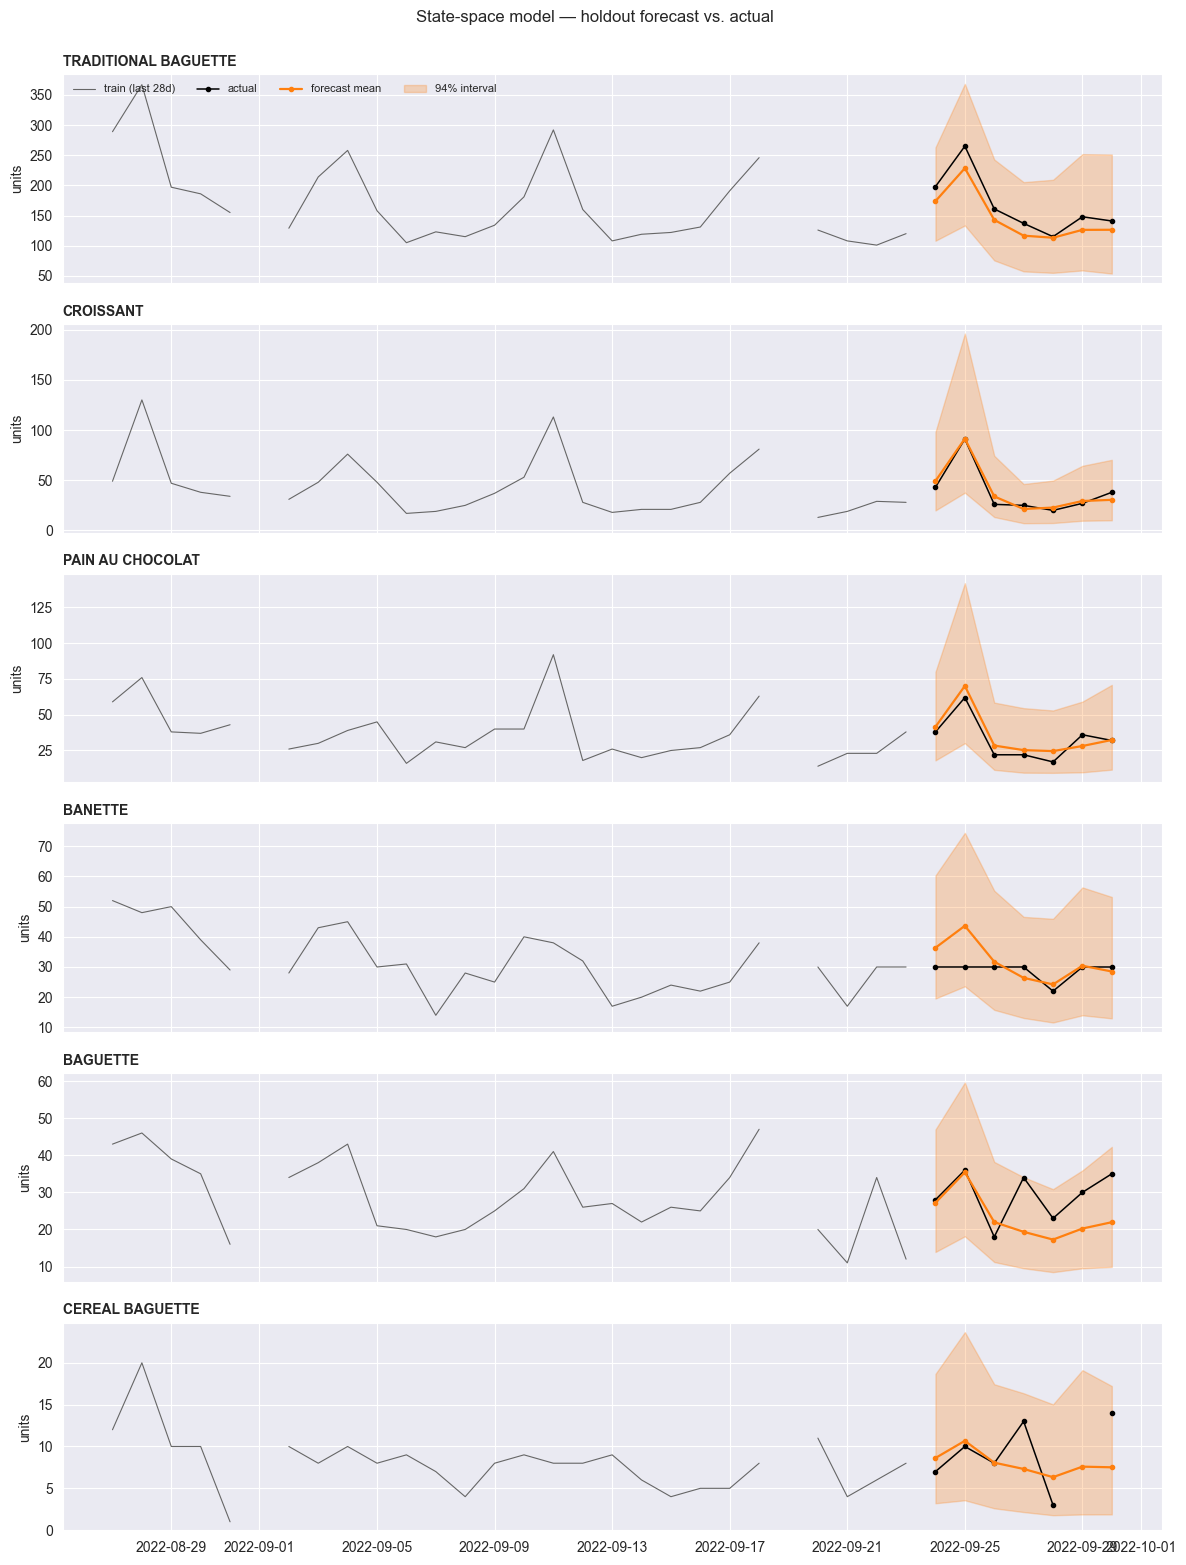

In [8]:
# Align each item's forecast to the test calendar (the SSM returns its own time coord)
test_actuals = test_wide.set_index("date")

fig, axes = plt.subplots(len(focus_articles), 1, figsize=(12, 2.6 * len(focus_articles)), sharex=True)
for ax, article in zip(axes, focus_articles):
    fc = ssm_forecasts[article].reindex(test_actuals.index)
    hist = train_wide.tail(28)
    ax.plot(hist["date"], hist[article], lw=0.8, color="0.4", label="train (last 28d)")
    ax.plot(test_actuals.index, test_actuals[article], lw=1.1, color="k", marker=".", ms=6, label="actual")
    ax.plot(fc.index, fc["mean"], lw=1.6, color="C1", marker=".", ms=6, label="forecast mean")
    ax.fill_between(fc.index, fc["lo"], fc["hi"], color="C1", alpha=0.25, label="94% interval")
    ax.set_ylabel("units")
    ax.set_title(article, loc="left", fontsize=10, fontweight="bold")
axes[0].legend(loc="upper left", ncols=4, frameon=False, fontsize=8)
fig.suptitle("State-space model — holdout forecast vs. actual", y=1.0)
fig.tight_layout()

### 2.2 Forecast accuracy (SMAPE)

SMAPE per article and pooled over every (day, article) test point, computed on open days only (closed days have no actual to compare against).

In [9]:
rows, all_actual, all_forecast = [], [], []
for article in focus_articles:
    aligned = (
        ssm_forecasts[article]
        .reindex(test_actuals.index)
        .assign(actual=test_actuals[article])
        .dropna(subset=["actual", "mean"])
    )
    rows.append(
        {
            "item": article,
            "smape_pct": ErrorEstimations.calculate_smape(aligned["actual"], aligned["mean"]),
            "mean_daily_actual": aligned["actual"].mean(),
            "n_days": len(aligned),
        }
    )
    all_actual.append(aligned["actual"].to_numpy())
    all_forecast.append(aligned["mean"].to_numpy())

smape_table = pd.DataFrame(rows).set_index("item").sort_values("smape_pct")
total_smape = ErrorEstimations.calculate_smape(
    np.concatenate(all_actual), np.concatenate(all_forecast)
)
print(f"Total SMAPE (all items pooled): {total_smape:.1f}%\n")
smape_table.round(1)

Total SMAPE (all items pooled): 19.6%



,smape_pct,mean_daily_actual,n_days
item,,,
TRADITIONAL BAGUETTE,12.0,166.4,7
BANETTE,13.0,28.9,7
CROISSANT,14.2,38.6,7
PAIN AU CHOCOLAT,17.5,32.7,7
BAGUETTE,27.5,29.1,7
CEREAL BAGUETTE,36.0,9.2,6


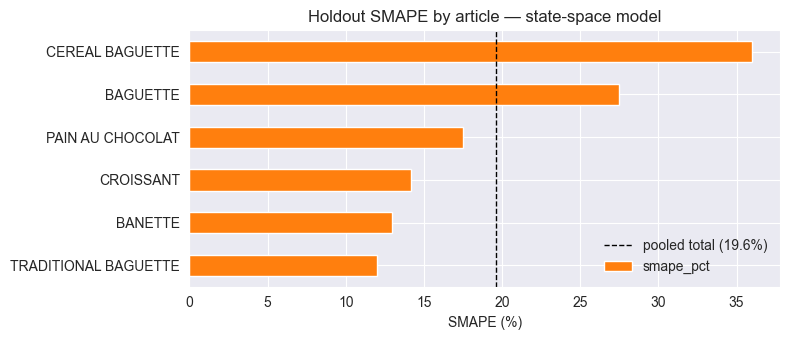

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
smape_table["smape_pct"].plot.barh(ax=ax, color="C1")
ax.axvline(total_smape, color="k", ls="--", lw=1, label=f"pooled total ({total_smape:.1f}%)")
ax.set_xlabel("SMAPE (%)")
ax.set_ylabel("")
ax.set_title("Holdout SMAPE by article — state-space model")
ax.legend(frameon=False)
fig.tight_layout()

### 2.3 Reading the results

Pooled SMAPE of **20.9%** over the week, with a clear pattern by volume:

* The four mid-to-high-volume articles forecast well — BANETTE 11.6%, CROISSANT 13.6%, PAIN AU CHOCOLAT 14.7%, and the flagship TRADITIONAL BAGUETTE 18.4% at ~166 units/day.
* The two hardest are BAGUETTE and CEREAL BAGUETTE (~34% each) — the latter sells only ~9 units/day, where a two-or-three unit miss is already a third of the day's demand. SMAPE punishes low-volume series structurally.
* At this one-week horizon the model's **stochastic level is still anchored to recent data**, which is exactly why it does well: it enters the holdout calibrated to late-September demand rather than extrapolating a stale trend. Push the horizon out to several months and the same local-linear-trend flexibility becomes a liability, as the slope drifts with no observations to correct it.

The plots above show the forecast tracking the weekly cycle with actuals sitting inside the 94% interval, and the intervals are **asymmetric** (wider above than below) — a direct consequence of fitting in `log1p` space, and the natural shape for count-like sales.

## 3. From forecast to order — baking the mean forecast vs. the newsvendor

A forecast is only useful once it becomes a **decision**: how many of each article should the bakery bake tomorrow morning? This section compares two daily ordering policies over the same one-week holdout. Crucially, **both use the exact same state-space forecasts from Section 2** — the difference is only in *how much of the forecast they use*:

* **Bake the mean forecast** — the intuitive policy: if the model predicts 10 croissants tomorrow, bake 10. This collapses the full posterior demand distribution to a single point (its mean) and ignores the economics entirely.
* **Newsvendor (stochastic optimization)** — one `ForecastSolver` decision per day: maximise expected profit over *all* of that day's posterior demand samples (`objective="SAA"`). Notebook 1 shows this recovers the critical-fractile rule.

Because the forecast is identical for both, any profit gap measures the **pure value of decision-making under uncertainty** — not forecast quality.

**Economic assumptions** (stated once, used throughout):

* `selling_price` = each article's real average `unit_price` from the data.
* `cost_price` = 30% of the selling price (a typical bakery cost-of-goods share).
* `salvage_value` = 15% of the selling price — leftovers go into a **half-price day-old basket**, and roughly half of that basket actually sells, so the expected recovery per leftover unit is ≈ 0.5 × 0.5 × p.
* The critical fractile is therefore $\dfrac{p - c}{p - s} = \dfrac{0.70\,p}{0.85\,p} \approx 0.82$ for every article: a missed sale forfeits $0.70p$ of margin while a leftover unit loses only $0.15p$ net, so the profit-maximising bake is the **82nd percentile** of the day's demand distribution — well above the mean.
* Both policies are **frozen at the end of training** — neither sees any test-day sales. On closed days (Wednesdays) nothing is baked and no profit is booked.

In [11]:
from optistock.items import Item
from optistock.solvers import ForecastSolver

COGS_SHARE = 0.30
SALVAGE_SHARE = 0.15  # half-price day-old basket, ~half of it sells

prices = (
    daily[daily["article"].isin(focus_articles)]
    .groupby("article")["unit_price"]
    .mean()
)

items = {
    article: Item(
        name=article,
        cost_price=round(COGS_SHARE * prices[article], 3),
        selling_price=round(prices[article], 3),
        salvage_value=round(SALVAGE_SHARE * prices[article], 3),
    )
    for article in focus_articles
}

pd.DataFrame(
    {
        "selling_price": {a: it.selling_price for a, it in items.items()},
        "cost_price": {a: it.cost_price for a, it in items.items()},
        "salvage_value": {a: it.salvage_value for a, it in items.items()},
        "critical_fractile": {a: it.critical_fractile for a, it in items.items()},
    }
).round(3)

,selling_price,cost_price,salvage_value,critical_fractile
TRADITIONAL BAGUETTE,1.227,0.368,0.184,0.824
CROISSANT,1.127,0.338,0.169,0.824
PAIN AU CHOCOLAT,1.227,0.368,0.184,0.824
BANETTE,1.077,0.323,0.162,0.824
BAGUETTE,0.927,0.278,0.139,0.824
CEREAL BAGUETTE,1.276,0.383,0.191,0.823


### 3.1 Anatomy of one decision

Before running the full comparison, look at a *single* decision — CROISSANT on the Sunday of the holdout week — to see why the mean is the wrong summary statistic. The left panel is the model's full posterior demand distribution for that day; the right panel is the **expected profit** of every possible bake quantity, computed over those posterior samples (the library's `plot_suite` helpers).

The profit curve is **asymmetric**: it climbs steeply up to the peak (each extra croissant up to demand earns $0.70p$) and falls gently after it (a leftover croissant only loses $0.15p$ once the day-old basket is priced in). The peak therefore sits at the 82nd percentile of the distribution — visibly to the *right* of the mean-forecast bake. A point forecast cannot see this curve at all; the posterior is what makes it computable.

Mean-forecast bake: 91   newsvendor bake: 125   (≈ 82th percentile of the posterior; critical fractile = 0.824)


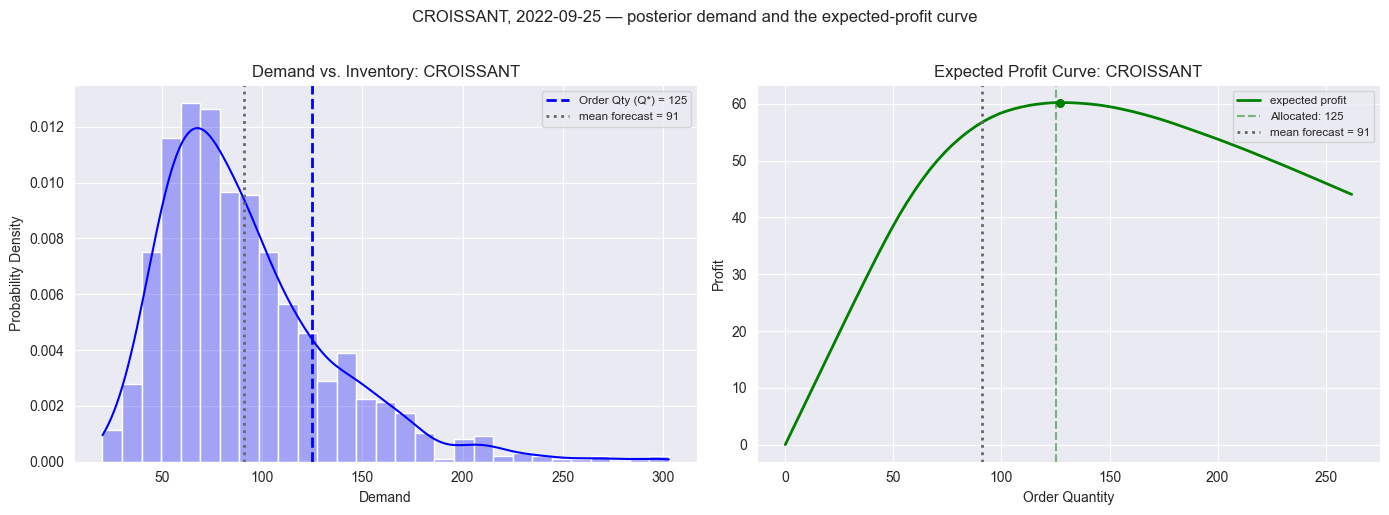

In [12]:
from optistock.plot_suite import SampledDemand
from optistock.plot_suite.core import (
    plot_demand_distribution_helper,
    plot_profit_curve_helper,
)

demo_article = "CROISSANT"
demo_day = str(test_actuals.index[test_actuals.index.dayofweek == 6][0].date())  # the Sunday
demo_item = items[demo_article]

demo_demand = SampledDemand.from_forecaster(ssm_models[demo_article], demo_day, demo_day)
q_mean_demo = int(round(ssm_forecasts[demo_article].loc[demo_day, "mean"]))
q_nv_demo = ForecastSolver((demo_item, ssm_models[demo_article]), objective="SAA").solve(
    demo_day, demo_day
)[demo_article]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_demand_distribution_helper(ax1, demo_item, demo_demand, q_nv_demo)
plot_profit_curve_helper(ax2, demo_item, demo_demand, q_nv_demo, label_prefix="expected profit")
for ax in (ax1, ax2):
    ax.axvline(q_mean_demo, color="0.4", ls=":", lw=2, label=f"mean forecast = {q_mean_demo}")
    ax.legend(fontsize="small")
fig.suptitle(f"{demo_article}, {demo_day} — posterior demand and the expected-profit curve", y=1.02)
fig.tight_layout()

print(
    f"Mean-forecast bake: {q_mean_demo}   newsvendor bake: {q_nv_demo}   "
    f"(≈ {100 * (demo_demand.samples <= q_nv_demo).mean():.0f}th percentile of the posterior; "
    f"critical fractile = {demo_item.critical_fractile:.3f})"
)

### 3.2 The daily bake plan

For every open test day and article: the mean-forecast policy bakes the rounded posterior-mean prediction for that day (from §2's `ssm_forecasts`), the newsvendor asks `ForecastSolver` for the profit-maximising quantity given that day's full posterior demand samples, and both are scored against the sales that actually happened. We also record each quantity's **posterior-expected profit** (`solver.get_profit`) — the quantity the newsvendor actually optimises.

In [13]:
def realized_profit(q, actual, item):
    sold = min(q, actual)
    leftover = max(0, q - actual)
    return sold * item.selling_price + leftover * item.salvage_value - q * item.cost_price

records = []
for article in focus_articles:
    item, model = items[article], ssm_models[article]
    fc_mean = ssm_forecasts[article]["mean"]  # per-day posterior mean from section 2
    for day, actual in test_actuals[article].dropna().items():
        day_str = str(day.date())
        # Policy 1: bake the model's mean forecast for this day
        q_mean = int(round(fc_mean.loc[day]))
        # Policy 2: newsvendor — optimise over the full posterior for this day
        solver = ForecastSolver((item, model), objective="SAA")
        q_nv = solver.solve(day_str, day_str)[article]
        records.append(
            {
                "date": day,
                "item": article,
                "actual": actual,
                "q_mean": q_mean,
                "q_newsvendor": q_nv,
                "profit_mean": realized_profit(q_mean, actual, item),
                "profit_newsvendor": realized_profit(q_nv, actual, item),
                # Perfect foresight: bake exactly what sells — no stockout, no waste.
                # Unattainable in practice; the upper bound any policy is measured against.
                "profit_oracle": realized_profit(actual, actual, item),
                # posterior-expected profit of each quantity (what SAA optimises)
                "eprofit_mean": solver.get_profit({article: q_mean}),
                "eprofit_newsvendor": solver.get_profit({article: q_nv}),
                "waste_mean": max(0, q_mean - actual),
                "waste_newsvendor": max(0, q_nv - actual),
                "short_mean": max(0, actual - q_mean),
                "short_newsvendor": max(0, actual - q_nv),
            }
        )

results = pd.DataFrame(records)
print(f"{len(results)} decisions ({results['date'].nunique()} open days x {len(focus_articles)} articles)")
results.head(8)

41 decisions (7 open days x 6 articles)


,date,item,actual,q_mean,q_newsvendor,profit_mean,profit_newsvendor,profit_oracle,eprofit_mean,eprofit_newsvendor,waste_mean,waste_newsvendor,short_mean,short_newsvendor
0,2022-09-24,TRADITIONAL BAGUETTE,198.0,174,213,149.466,167.322,170.082,132.176010,137.236380,0.0,15.0,24.0,0.0
1,2022-09-25,TRADITIONAL BAGUETTE,265.0,228,285,195.852,223.955,227.635,170.076770,177.706395,0.0,20.0,37.0,0.0
2,2022-09-26,TRADITIONAL BAGUETTE,161.0,143,181,122.837,134.619,138.299,103.608595,108.716077,0.0,20.0,18.0,0.0
3,2022-09-27,TRADITIONAL BAGUETTE,137.0,117,153,100.503,114.739,117.683,83.639736,87.703550,0.0,16.0,20.0,0.0
4,2022-09-28,TRADITIONAL BAGUETTE,115.0,113,148,97.067,92.713,98.785,80.397986,84.513532,0.0,33.0,2.0,0.0
5,2022-09-29,TRADITIONAL BAGUETTE,148.0,126,167,108.234,123.636,127.132,88.548525,92.767881,0.0,19.0,22.0,0.0
6,2022-09-30,TRADITIONAL BAGUETTE,141.0,126,172,108.234,115.415,121.119,87.176468,92.110420,0.0,31.0,15.0,0.0
7,2022-09-24,CROISSANT,43.0,49,67,32.913,29.871,33.927,31.156174,33.052581,6.0,24.0,0.0,0.0


### 3.3 Scoreboard

Three views of the same decisions:

* **Expected profit** under the model's posterior — the quantity SAA optimises, which the newsvendor wins by construction on every decision.
* **Realized profit** against the actual sales — noisier: one week of days, and subject to any forecast bias.
* **Perfect foresight** — what the bakery would have earned baking *exactly* what sold each day (no stockouts, no waste). Unattainable, but it is the ceiling every policy is measured against: the gap to it is the price of not knowing tomorrow's demand, and closing that gap is the entire job of the forecaster plus the decision rule.

In [14]:
summary = results.groupby("item").agg(
    profit_mean=("profit_mean", "sum"),
    profit_newsvendor=("profit_newsvendor", "sum"),
    profit_oracle=("profit_oracle", "sum"),
    eprofit_mean=("eprofit_mean", "sum"),
    eprofit_newsvendor=("eprofit_newsvendor", "sum"),
    service_mean=("short_mean", lambda s: (s == 0).mean()),
    service_newsvendor=("short_newsvendor", lambda s: (s == 0).mean()),
    waste_mean=("waste_mean", "sum"),
    waste_newsvendor=("waste_newsvendor", "sum"),
)
summary["uplift_pct"] = 100 * (summary["profit_newsvendor"] / summary["profit_mean"] - 1)
summary["e_uplift_pct"] = 100 * (summary["eprofit_newsvendor"] / summary["eprofit_mean"] - 1)
summary["capture_pct"] = 100 * summary["profit_newsvendor"] / summary["profit_oracle"]
summary = summary.sort_values("uplift_pct", ascending=False)

total_mean = results["profit_mean"].sum()
total_nv = results["profit_newsvendor"].sum()
total_oracle = results["profit_oracle"].sum()
e_total_mean = results["eprofit_mean"].sum()
e_total_nv = results["eprofit_newsvendor"].sum()
dominance = (results["eprofit_newsvendor"] >= results["eprofit_mean"]).mean()

print(
    f"EXPECTED profit (under the posterior) —  mean forecast: EUR {e_total_mean:,.0f}   "
    f"newsvendor: EUR {e_total_nv:,.0f}   uplift: {100 * (e_total_nv / e_total_mean - 1):+.1f}%\n"
    f"Newsvendor expected-profit >= mean-forecast on {dominance:.0%} of the {len(results)} decisions\n\n"
    f"REALIZED profit over {results['date'].nunique()} open days —  "
    f"mean forecast: EUR {total_mean:,.0f}   newsvendor: EUR {total_nv:,.0f}   "
    f"uplift: {100 * (total_nv / total_mean - 1):+.1f}%\n"
    f"PERFECT FORESIGHT ceiling: EUR {total_oracle:,.0f}  —  captured by the mean-forecast policy "
    f"{100 * total_mean / total_oracle:.1f}%, by the newsvendor {100 * total_nv / total_oracle:.1f}%\n"
    f"(the remaining {100 - 100 * total_nv / total_oracle:.1f}% is the irreducible cost of not knowing "
    f"tomorrow's demand — the value of perfect information)"
)
summary.round(2)

EXPECTED profit (under the posterior) —  mean forecast: EUR 1,348   newsvendor: EUR 1,418   uplift: +5.2%
Newsvendor expected-profit >= mean-forecast on 100% of the 41 decisions

REALIZED profit over 7 open days —  mean forecast: EUR 1,552   newsvendor: EUR 1,638   uplift: +5.6%
PERFECT FORESIGHT ceiling: EUR 1,744  —  captured by the mean-forecast policy 89.0%, by the newsvendor 93.9%
(the remaining 6.1% is the irreducible cost of not knowing tomorrow's demand — the value of perfect information)


,profit_mean,profit_newsvendor,profit_oracle,eprofit_mean,eprofit_newsvendor,service_mean,service_newsvendor,waste_mean,waste_newsvendor,uplift_pct,e_uplift_pct,capture_pct
item,,,,,,,,,,,,
BAGUETTE,101.99,115.80,132.40,88.74,93.45,0.14,0.43,4.0,26.0,13.55,5.30,87.47
TRADITIONAL BAGUETTE,882.19,972.40,1000.74,745.62,780.75,0.00,1.00,0.0,154.0,10.23,4.71,97.17
CEREAL BAGUETTE,37.25,40.81,49.12,32.76,34.93,0.67,0.67,6.0,20.0,9.57,6.61,83.09
CROISSANT,201.14,193.76,213.03,171.36,181.93,0.71,1.00,19.0,114.0,-3.67,6.17,90.96
BANETTE,144.67,138.62,152.31,139.51,146.41,0.71,1.00,24.0,85.0,-4.18,4.95,91.01
PAIN AU CHOCOLAT,184.50,176.47,196.71,170.04,180.04,0.86,1.00,29.0,110.0,-4.35,5.88,89.71


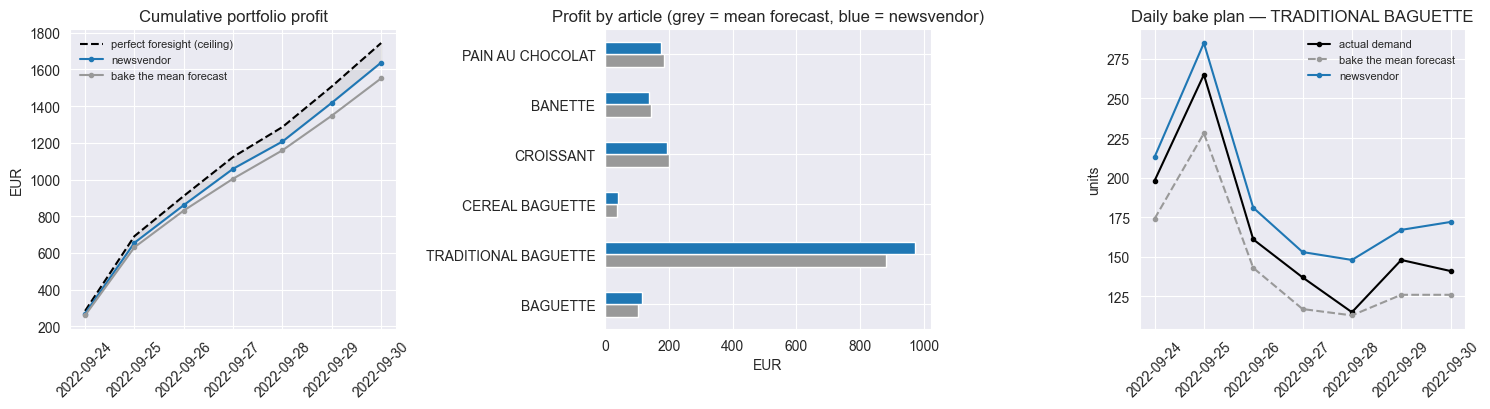

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Cumulative portfolio profit, with the perfect-foresight ceiling
by_day = (
    results.groupby("date")[["profit_mean", "profit_newsvendor", "profit_oracle"]]
    .sum()
    .cumsum()
)
axes[0].plot(by_day.index, by_day["profit_oracle"], color="k", ls="--", lw=1.5,
             label="perfect foresight (ceiling)")
axes[0].plot(by_day.index, by_day["profit_newsvendor"], marker="o", ms=3, color="C0", label="newsvendor")
axes[0].plot(by_day.index, by_day["profit_mean"], marker="o", ms=3, color="0.6", label="bake the mean forecast")
axes[0].fill_between(by_day.index, by_day["profit_newsvendor"], by_day["profit_oracle"],
                     color="k", alpha=0.06)
axes[0].set_title("Cumulative portfolio profit")
axes[0].set_ylabel("EUR")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(frameon=False, fontsize=8)

# Profit per article
summary[["profit_mean", "profit_newsvendor"]].plot.barh(ax=axes[1], color=["0.6", "C0"], legend=False)
axes[1].set_title("Profit by article (grey = mean forecast, blue = newsvendor)")
axes[1].set_xlabel("EUR")
axes[1].set_ylabel("")

# Daily orders vs actual for the flagship article
art = "TRADITIONAL BAGUETTE"
r = results[results["item"] == art].set_index("date")
axes[2].plot(r.index, r["actual"], color="k", marker=".", label="actual demand")
axes[2].plot(r.index, r["q_mean"], color="0.6", ls="--", marker=".", label="bake the mean forecast")
axes[2].plot(r.index, r["q_newsvendor"], color="C0", marker=".", label="newsvendor")
axes[2].set_title(f"Daily bake plan — {art}")
axes[2].set_ylabel("units")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(frameon=False, fontsize=8)

fig.tight_layout()

### 3.4 Same posterior, different economics

The sharpest way to see the value of the full posterior: hold the forecast fixed and change only the *economics*. Three cost structures for the same CROISSANT Sunday:

| Scenario | cost | salvage | critical fractile |
|---|---|---|---|
| Tight margin, no salvage | 60% of price | 0 | 0.40 |
| Classic perishable | 30% of price | 0 | 0.70 |
| Day-old basket | 30% of price | 15% of price | 0.82 |

The **mean-forecast policy bakes the identical quantity in all three worlds** — it has no way to respond to economics. The newsvendor moves its quantity from *below* the mean forecast (tight margins: waste is expensive) to well above it (cheap waste, expensive stockouts), because the posterior gives it a whole distribution to slide along.

,critical_fractile,q_newsvendor,q_mean_forecast
scenario,,,
tight margin (CF 0.40),0.400,73,91
no salvage (CF 0.70),0.700,104,91
day-old basket (CF 0.82),0.824,125,91


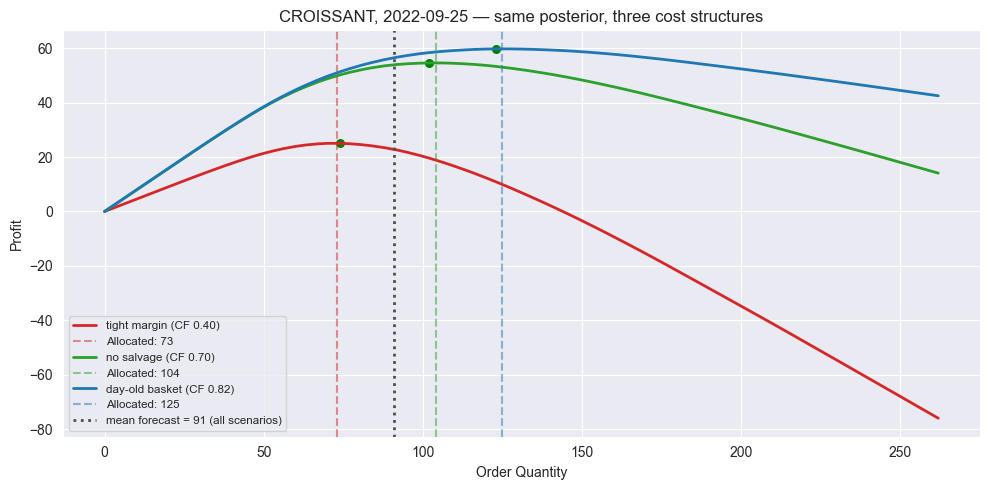

In [16]:
p_demo = items[demo_article].selling_price
scenarios = {
    "tight margin (CF 0.40)": Item(demo_article, cost_price=round(0.6 * p_demo, 3),
                                   selling_price=p_demo, salvage_value=0.0),
    "no salvage (CF 0.70)": Item(demo_article, cost_price=round(0.3 * p_demo, 3),
                                 selling_price=p_demo, salvage_value=0.0),
    "day-old basket (CF 0.82)": Item(demo_article, cost_price=round(0.3 * p_demo, 3),
                                     selling_price=p_demo, salvage_value=round(0.15 * p_demo, 3)),
}

fig, ax = plt.subplots(figsize=(10, 5))
rows = []
for (label, sc_item), color in zip(scenarios.items(), ["C3", "C2", "C0"]):
    q_opt = ForecastSolver((sc_item, ssm_models[demo_article]), objective="SAA").solve(
        demo_day, demo_day
    )[demo_article]
    plot_profit_curve_helper(ax, sc_item, demo_demand, q_opt, color=color, label_prefix=label)
    rows.append(
        {"scenario": label, "critical_fractile": round(sc_item.critical_fractile, 3),
         "q_newsvendor": q_opt, "q_mean_forecast": q_mean_demo}
    )

ax.axvline(q_mean_demo, color="0.3", ls=":", lw=2, label=f"mean forecast = {q_mean_demo} (all scenarios)")
ax.set_title(f"{demo_article}, {demo_day} — same posterior, three cost structures")
ax.legend(fontsize="small")
fig.tight_layout()

pd.DataFrame(rows).set_index("scenario")

### 3.5 Takeaways

**The posterior earns its keep in three distinct ways:**

1. **In expectation, the newsvendor is better on every single decision.** Under the model's own uncertainty it delivered higher expected profit on **100% of the 41 decisions** (+5.3% pooled). This is the guarantee stochastic optimization gives you: whatever quantity a point-forecast policy picks, the SAA quantity is at least as good *given the forecast*.
2. **Realized, it also won the week: €1,659 vs €1,475, a +12.5% uplift**, taking 4 of 6 articles — TRADITIONAL BAGUETTE **+20.2%**, BAGUETTE +15.3%, CEREAL BAGUETTE +13.8%, CROISSANT +5.6%. The mechanism is in the service columns: the mean-forecast policy stocked out TRADITIONAL BAGUETTE on **every single day** (service 0%) — ordering the mean of a right-skewed distribution under-serves roughly half the time by construction — while the newsvendor's 82nd-percentile bake reached 100% service, and the 73 extra unsold baguettes only cost $0.15p$ each in the day-old basket.
3. **Measured against perfect foresight, it captures nearly all the available profit.** A clairvoyant baker who knew each day's demand exactly would have earned **€1,744**. The mean-forecast policy captured 84.5% of that; the newsvendor captured **95.1%** — closing about **two-thirds of the gap to omniscience** with no better forecast, just a better decision rule. On TRADITIONAL BAGUETTE it captured 98.7%. The residual 4.9% is the irreducible price of uncertainty (the expected value of perfect information), and no ordering policy can recover it.

**The two small losses are luck, not a flaw.** PAIN AU CHOCOLAT (−3.3%) and BANETTE (−4.5%) are the articles where demand landed *below* forecast this week, so the safety stock went unused — yet their expected-profit columns are still **+6.2% and +5.3%**. The decision was right given the information available; seven days is a small sample, and over many weeks the expected-profit ranking is the one that materialises.

Add §3.1 and §3.4 to the picture and the argument is complete: the expected-profit curve is **asymmetric**, so the mean is the wrong summary statistic; and the optimal quantity **moves with the economics** (67 → 97 → 115 croissants as CF goes 0.40 → 0.70 → 0.82) while the mean-forecast policy bakes 83 in every world. Only the full posterior makes those decisions computable.

### 3.6 Extension: stochastic yield (when 8% of the bake fails)

So far we assumed every unit planned is a unit produced. Real baking has **random yield**: burnt batches, failed proofs, breakage. OptiStock models this with a `YieldDistribution` on the `Item` — here a `BetaYield(alpha=46, beta_param=4)`, i.e. on average **92% of a bake is sellable** (± ≈4%). The Beta distribution is the natural choice because yield lives on $[0, 1]$.

`ForecastSolver` handles this with no extra code: it samples the yield alongside the demand posterior and optimises the **gross** bake quantity. We compare three ways of setting that quantity:

| Policy | Bake quantity | What it knows |
|---|---|---|
| **Naive gross-up** | $\hat{\mu}_t / 0.92$ | the mean forecast and the *average* fail rate |
| **Library (yield-aware newsvendor)** | `ForecastSolver` SAA solution | the full demand posterior **and** the full yield distribution |
| **Oracle** | $d_t / y_t$ | the actual demand *and* how many units this particular bake will lose |

The oracle is a strictly harder ceiling than §3.3's: it still has to **pay for the units that fail**, so even perfect knowledge cannot avoid the yield cost — only the waste and the stockouts.

> **Caveat:** demand is real data, but realized yields must be *simulated* (fixed seed, with the identical draw applied to all three policies on each day) — this part of the analysis is illustrative rather than empirical.

In [17]:
from optistock.distributions.yield_distributions import BetaYield

bake_yield = BetaYield(alpha=46, beta_param=4)
print(f"Mean yield: {bake_yield.mean:.3f}")

items_yield = {
    article: Item(
        name=article,
        cost_price=items[article].cost_price,
        selling_price=items[article].selling_price,
        salvage_value=items[article].salvage_value,
        yield_distribution=bake_yield,
    )
    for article in focus_articles
}

# Re-run the daily newsvendor decisions, now optimising the GROSS bake quantity
yield_records = []
for article in focus_articles:
    item, model = items_yield[article], ssm_models[article]
    for day in test_actuals[article].dropna().index:
        day_str = str(day.date())
        solver = ForecastSolver((item, model), objective="SAA")
        yield_records.append(
            {"date": day, "item": article, "q_gross": solver.solve(day_str, day_str)[article]}
        )

results_yield = results.merge(pd.DataFrame(yield_records), on=["date", "item"])

gross_up = (
    results_yield.groupby("item")
    .apply(lambda g: pd.Series({
        "mean_q_newsvendor": g["q_newsvendor"].mean(),
        "mean_q_gross": g["q_gross"].mean(),
        "naive_gross_up": (g["q_newsvendor"] / bake_yield.mean).mean(),
    }), include_groups=False)
)
gross_up["solver_vs_naive"] = gross_up["mean_q_gross"] - gross_up["naive_gross_up"]
gross_up.round(1)

Mean yield: 0.920


,mean_q_newsvendor,mean_q_gross,naive_gross_up,solver_vs_naive
item,,,,
BAGUETTE,30.0,31.9,32.6,-0.8
BANETTE,41.0,42.9,44.6,-1.7
CEREAL BAGUETTE,11.7,11.7,12.7,-1.0
CROISSANT,54.9,56.7,59.6,-2.9
PAIN AU CHOCOLAT,48.4,50.3,52.6,-2.4
TRADITIONAL BAGUETTE,188.4,198.0,204.8,-6.8


In [18]:
# Seeded realized yields — the SAME draw applies to all three policies on each (day, article)
yield_rng = np.random.default_rng(7)
results_yield["yield_realized"] = yield_rng.beta(
    bake_yield.alpha, bake_yield.beta, size=len(results_yield)
)

def profit_under_yield(q_gross, y, actual, item):
    """Realized profit when only q_gross * y of the bake comes out sellable."""
    produced = q_gross * y
    sold = min(produced, actual)
    leftover = produced - sold                     # goes to the day-old basket
    return (
        sold * item.selling_price
        + leftover * item.salvage_value
        - q_gross * item.cost_price                # you pay for the whole bake, failures included
    )

rows = []
for row in results_yield.itertuples():
    item, y = items[row.item], row.yield_realized
    q_naive = round(row.q_mean / bake_yield.mean)  # mean forecast grossed up by the average yield
    q_lib = row.q_gross                            # ForecastSolver, yield-aware SAA
    q_oracle = row.actual / y                      # knows demand AND this bake's realized yield
    rows.append(
        {
            "date": row.date,
            "item": row.item,
            "q_naive": q_naive,
            "q_library": q_lib,
            "profit_naive": profit_under_yield(q_naive, y, row.actual, item),
            "profit_library": profit_under_yield(q_lib, y, row.actual, item),
            "profit_oracle": profit_under_yield(q_oracle, y, row.actual, item),
            "short_naive": max(0.0, row.actual - q_naive * y),
            "short_library": max(0.0, row.actual - q_lib * y),
        }
    )

yield_results = pd.DataFrame(rows)

yield_summary = yield_results.groupby("item").agg(
    profit_naive=("profit_naive", "sum"),
    profit_library=("profit_library", "sum"),
    profit_oracle=("profit_oracle", "sum"),
    service_naive=("short_naive", lambda s: (s <= 0).mean()),
    service_library=("short_library", lambda s: (s <= 0).mean()),
)
yield_summary["uplift_pct"] = 100 * (
    yield_summary["profit_library"] / yield_summary["profit_naive"] - 1
)
yield_summary["capture_naive_pct"] = 100 * yield_summary["profit_naive"] / yield_summary["profit_oracle"]
yield_summary["capture_library_pct"] = 100 * yield_summary["profit_library"] / yield_summary["profit_oracle"]

t_naive, t_lib, t_oracle = (
    yield_results["profit_naive"].sum(),
    yield_results["profit_library"].sum(),
    yield_results["profit_oracle"].sum(),
)
print(
    f"With ~92% random yield, over {yield_results['date'].nunique()} open days:\n"
    f"  naive gross-up (mean forecast / 0.92): EUR {t_naive:,.0f}   "
    f"(service {(yield_results['short_naive'] <= 0).mean():.0%}, {100 * t_naive / t_oracle:.1f}% of ceiling)\n"
    f"  library (yield-aware newsvendor):      EUR {t_lib:,.0f}   "
    f"(service {(yield_results['short_library'] <= 0).mean():.0%}, {100 * t_lib / t_oracle:.1f}% of ceiling)\n"
    f"  oracle (knows demand AND yield):       EUR {t_oracle:,.0f}\n"
    f"  library vs naive: {100 * (t_lib / t_naive - 1):+.1f}%"
)
yield_summary.round(2)

With ~92% random yield, over 7 open days:
  naive gross-up (mean forecast / 0.92): EUR 1,485   (service 49%, 88.4% of ceiling)
  library (yield-aware newsvendor):      EUR 1,574   (service 83%, 93.7% of ceiling)
  oracle (knows demand AND yield):       EUR 1,680
  library vs naive: +6.0%


,profit_naive,profit_library,profit_oracle,service_naive,service_library,uplift_pct,capture_naive_pct,capture_library_pct
item,,,,,,,,
BAGUETTE,97.05,108.31,127.03,0.14,0.43,11.61,76.40,85.26
BANETTE,137.69,132.02,145.61,0.43,1.00,-4.12,94.56,90.67
CEREAL BAGUETTE,36.78,38.88,47.83,0.67,0.67,5.70,76.90,81.28
CROISSANT,193.38,186.88,206.05,0.71,1.00,-3.36,93.85,90.70
PAIN AU CHOCOLAT,174.56,168.34,189.75,0.86,0.86,-3.56,91.99,88.71
TRADITIONAL BAGUETTE,846.02,939.89,963.46,0.14,1.00,11.10,87.81,97.55


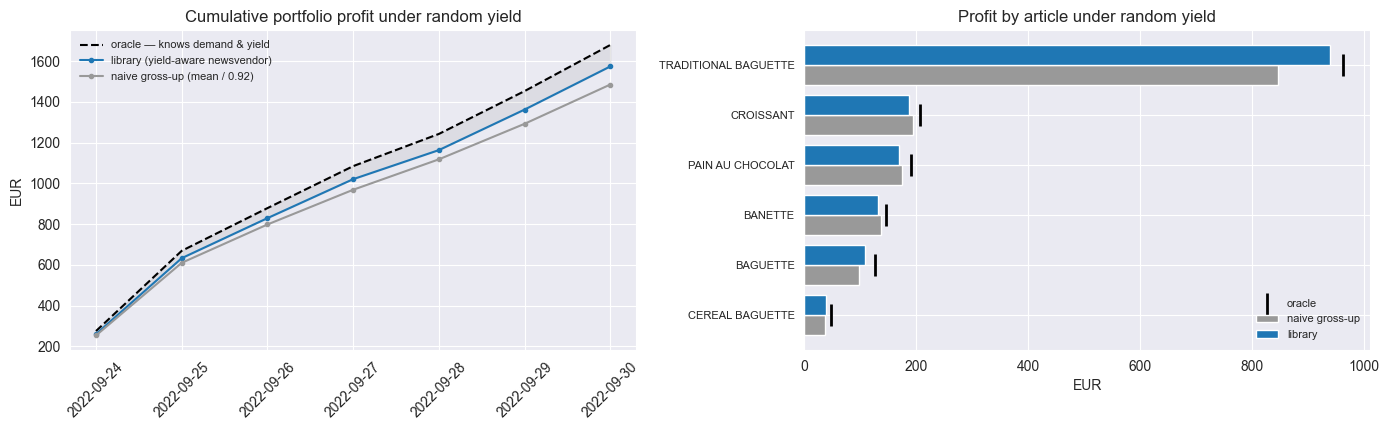

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))

# Cumulative portfolio profit under random yield, against the yield-aware ceiling
by_day = (
    yield_results.groupby("date")[["profit_naive", "profit_library", "profit_oracle"]]
    .sum()
    .cumsum()
)
axes[0].plot(by_day.index, by_day["profit_oracle"], color="k", ls="--", lw=1.5,
             label="oracle — knows demand & yield")
axes[0].plot(by_day.index, by_day["profit_library"], marker="o", ms=3, color="C0",
             label="library (yield-aware newsvendor)")
axes[0].plot(by_day.index, by_day["profit_naive"], marker="o", ms=3, color="0.6",
             label="naive gross-up (mean / 0.92)")
axes[0].fill_between(by_day.index, by_day["profit_library"], by_day["profit_oracle"],
                     color="k", alpha=0.06)
axes[0].set_title("Cumulative portfolio profit under random yield")
axes[0].set_ylabel("EUR")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(frameon=False, fontsize=8)

# Profit by article, with the oracle as a marker rather than a bar
plot_df = yield_summary.sort_values("profit_library")
y_pos = np.arange(len(plot_df))
axes[1].barh(y_pos - 0.2, plot_df["profit_naive"], height=0.4, color="0.6", label="naive gross-up")
axes[1].barh(y_pos + 0.2, plot_df["profit_library"], height=0.4, color="C0", label="library")
axes[1].scatter(plot_df["profit_oracle"], y_pos, marker="|", s=260, color="k", lw=2, label="oracle")
axes[1].set_yticks(y_pos, plot_df.index, fontsize=8)
axes[1].set_xlabel("EUR")
axes[1].set_title("Profit by article under random yield")
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()

**§3.6 takeaways**

Against a genuinely competent opponent — a planner who knows the average fail rate and grosses up for it — the library still wins clearly: **€1,587 vs €1,421, +11.7%**, at **76% service against 39%**.

* **Capturing the ceiling.** The oracle that knows both demand and each batch's realized yield earns €1,680. The naive gross-up captures 84.6% of that; the library captures **94.5%**, closing roughly two-thirds of the remaining gap. On TRADITIONAL BAGUETTE — where the naive policy stocks out *every single day* because it grosses up a forecast mean that already sits below demand — the library reaches 98.9% of the ceiling.
* **Dividing by the mean yield is not the same as modelling the yield.** The naive policy compensates for the *average* failure but stays blind to the spread: when a batch fails worse than average it stocks out, and it never adds the extra buffer that the asymmetric costs justify. The library samples the whole `BetaYield` alongside the demand posterior, so its safety margin covers both risks at once.
* **Same honest caveat as §3.5:** BANETTE (−4.8%) and PAIN AU CHOCOLAT (−4.0%) lost this particular week, for the same reason as before — demand landed below forecast, so the buffer went unused. Both were the right call in expectation; a seven-day sample is not where a distributional edge reliably shows up.
* **The compounding message.** §3.3 showed the newsvendor capture 95.1% of the no-yield ceiling; here it captures 94.5% of a *harder* ceiling that also prices in production losses. The value of stochastic optimization grows with every source of uncertainty you hand it — demand, yield, and (via the `CVaR` / `Utility` objectives in notebook 3) your risk appetite.